***import libraries***


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
import matplotlib.pyplot as plt
import pandas as pd


***Load & Preprocess***

In [ ]:
# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Flatten images for MLP
x_train = x_train.reshape(-1, 28*28)
x_test = x_test.reshape(-1, 28*28)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


***Plot Function (Training vs Validation)***

In [ ]:
def plot_history(history, title):
    plt.figure(figsize=(12,4))

    # Loss plot
    plt.subplot(1,2,1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(title + " - Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid()

    # Accuracy plot
    plt.subplot(1,2,2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(title + " - Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid()

    plt.show()


***Baseline Model (No Regularization)***

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.8479 - loss: 0.5403 - val_accuracy: 0.9583 - val_loss: 0.1447
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9641 - loss: 0.1206 - val_accuracy: 0.9693 - val_loss: 0.1032
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9774 - loss: 0.0751 - val_accuracy: 0.9701 - val_loss: 0.0994
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9845 - loss: 0.0528 - val_accuracy: 0.9739 - val_loss: 0.0898
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9890 - loss: 0.0354 - val_accuracy: 0.9743 - val_loss: 0.0914
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9913 - loss: 0.0294 - val_accuracy: 0.9765 - val_loss: 0.0871
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9937 - loss: 0.0209 - val_accuracy: 0.9783 - val_loss: 0.0885
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9955 - loss: 0.0155 - val_accuracy

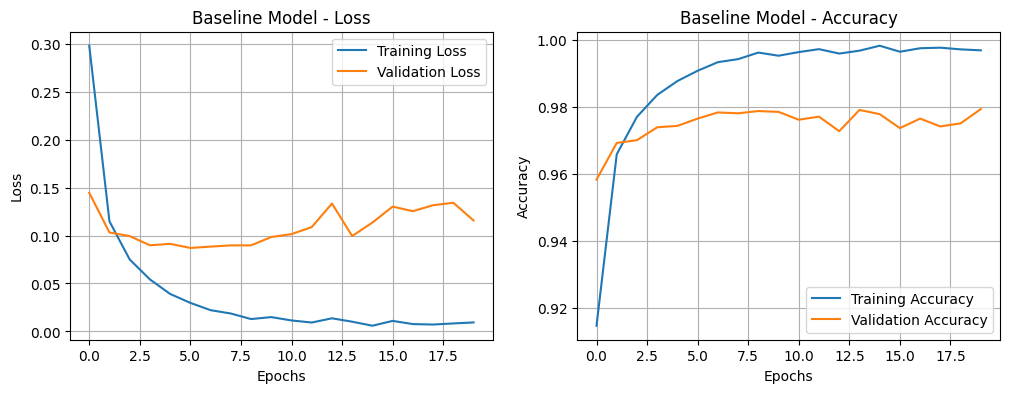

In [ ]:
baseline_model = models.Sequential([
    layers.Dense(256, activation='relu', input_shape=(784,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

baseline_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_baseline = baseline_model.fit(
    x_train, y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.2
)

plot_history(history_baseline, "Baseline Model")


***Batch Normalization***

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.8673 - loss: 0.4593 - val_accuracy: 0.9625 - val_loss: 0.1267
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9748 - loss: 0.0892 - val_accuracy: 0.9728 - val_loss: 0.0884
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9851 - loss: 0.0517 - val_accuracy: 0.9721 - val_loss: 0.0928
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9905 - loss: 0.0342 - val_accuracy: 0.9741 - val_loss: 0.0866
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9933 - loss: 0.0240 - val_accuracy: 0.9748 - val_loss: 0.0768
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9950 - loss: 0.0182 - val_accuracy: 0.9766 - val_loss: 0.0881
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9954 - loss: 0.0170 - val_accuracy: 0.9778 - val_loss: 0.0792
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9965 - loss: 0.0121 - val_accu

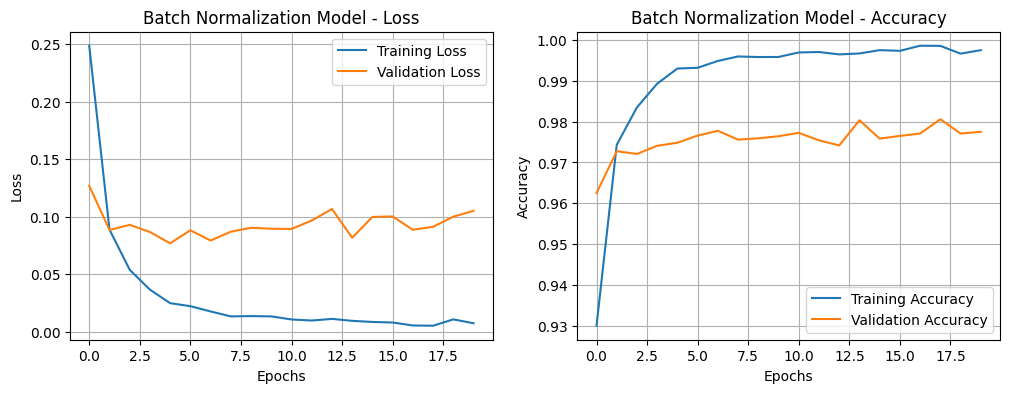

In [ ]:
bn_model = models.Sequential([
    layers.Dense(256, input_shape=(784,)),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.Dense(128),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.Dense(10, activation='softmax')
])

bn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_bn = bn_model.fit(
    x_train, y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.2
)

plot_history(history_bn, "Batch Normalization Model")


***L2 Regularization***

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.8361 - loss: 0.9567 - val_accuracy: 0.9492 - val_loss: 0.4016
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9546 - loss: 0.3627 - val_accuracy: 0.9620 - val_loss: 0.2996
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9670 - loss: 0.2752 - val_accuracy: 0.9680 - val_loss: 0.2481
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9704 - loss: 0.2313 - val_accuracy: 0.9718 - val_loss: 0.2187
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9739 - loss: 0.2047 - val_accuracy: 0.9657 - val_loss: 0.2179
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9762 - loss: 0.1865 - val_accuracy: 0.9693 - val_loss: 0.2053
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9774 - loss: 0.1759 - val_accuracy: 0.9707 - val_loss: 0.1908
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9788 - loss: 0.1681 - val_accura

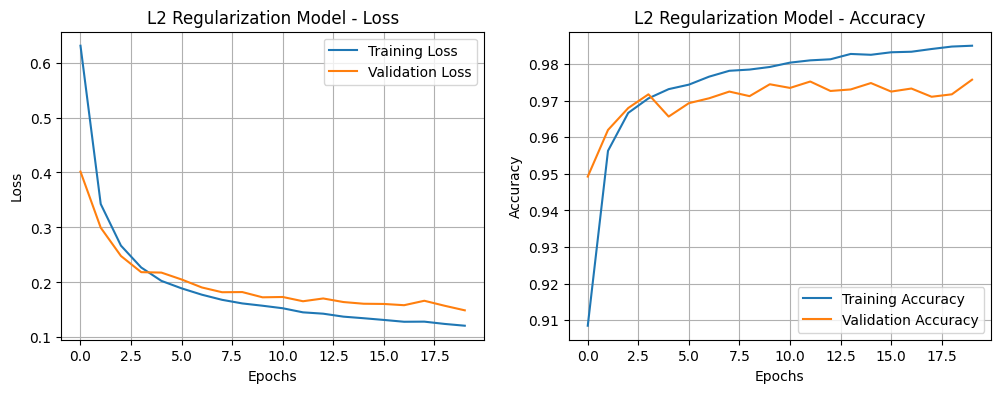

In [ ]:
l2_model = models.Sequential([
    layers.Dense(256, activation='relu',
                 kernel_regularizer=regularizers.l2(0.001),
                 input_shape=(784,)),
    layers.Dense(128, activation='relu',
                 kernel_regularizer=regularizers.l2(0.001)),
    layers.Dense(10, activation='softmax')
])

l2_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_l2 = l2_model.fit(
    x_train, y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.2
)

plot_history(history_l2, "L2 Regularization Model")


***Dropout Regularization***

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.6861 - loss: 0.9616 - val_accuracy: 0.9457 - val_loss: 0.1846
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9174 - loss: 0.2857 - val_accuracy: 0.9600 - val_loss: 0.1362
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9381 - loss: 0.2092 - val_accuracy: 0.9649 - val_loss: 0.1164
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9488 - loss: 0.1767 - val_accuracy: 0.9678 - val_loss: 0.1102
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9545 - loss: 0.1577 - val_accuracy: 0.9703 - val_loss: 0.0961
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9588 - loss: 0.1391 - val_accuracy: 0.9719 - val_loss: 0.0946
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9613 - loss: 0.1267 - val_accuracy: 0.9739 - val_loss: 0.0891
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9640 - loss: 0.1179 - val_accuracy:

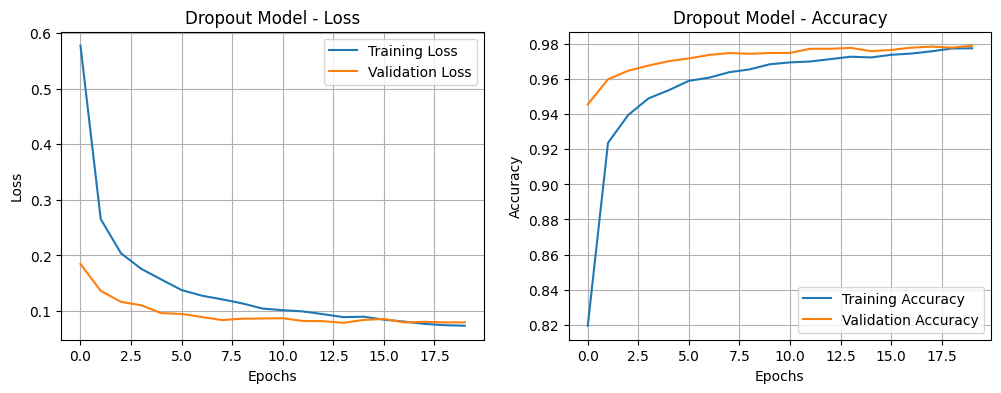

In [ ]:
dropout_model = models.Sequential([
    layers.Dense(256, activation='relu', input_shape=(784,)),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

dropout_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_dropout = dropout_model.fit(
    x_train, y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.2
)

plot_history(history_dropout, "Dropout Model")


***combined loss graph***

NameError: name 'history_dropout' is not defined

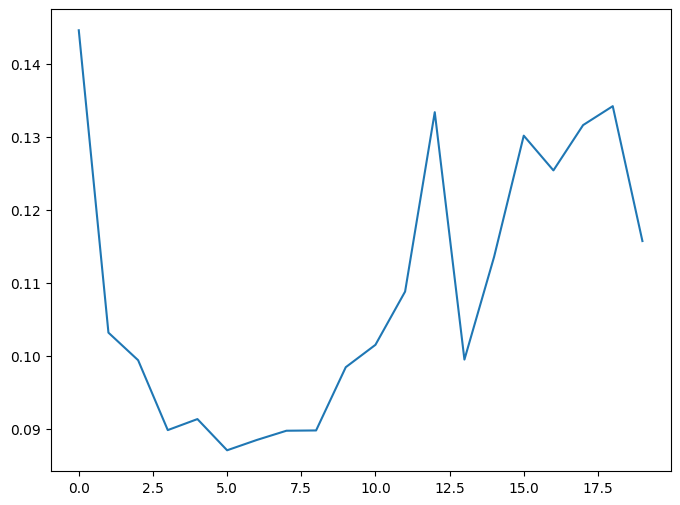

In [ ]:
plt.figure(figsize=(8,6))
plt.plot(history_baseline.history['val_loss'], label='Baseline')
plt.plot(history_dropout.history['val_loss'], label='Dropout')
plt.plot(history_l2.history['val_loss'], label='L2')
plt.plot(history_bn.history['val_loss'], label='BatchNorm')

plt.title("Validation Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()


***Combined Validation Accuracy Comparison Graph***

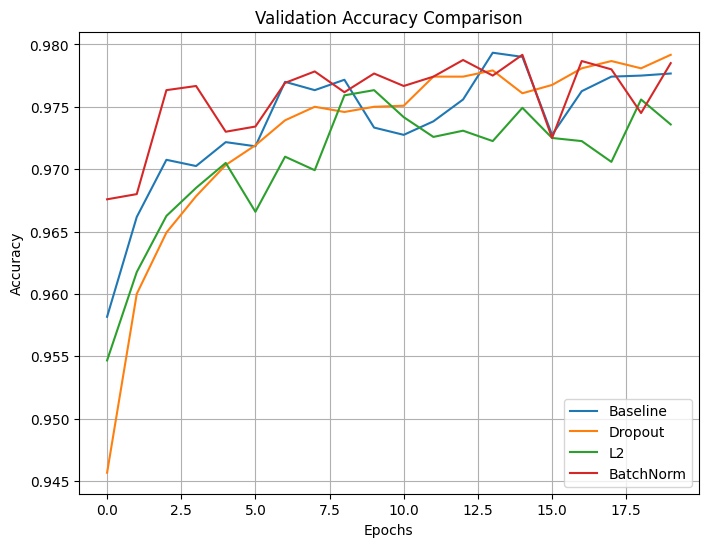

In [ ]:
plt.figure(figsize=(8,6))
plt.plot(history_baseline.history['val_accuracy'], label='Baseline')
plt.plot(history_dropout.history['val_accuracy'], label='Dropout')
plt.plot(history_l2.history['val_accuracy'], label='L2')
plt.plot(history_bn.history['val_accuracy'], label='BatchNorm')

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()


In [ ]:
results = {
    "Model": ["Baseline", "Dropout", "L2 Regularization", "Batch Normalization"],
    "Test Accuracy": [
        baseline_model.evaluate(x_test, y_test, verbose=0)[1],
        dropout_model.evaluate(x_test, y_test, verbose=0)[1],
        l2_model.evaluate(x_test, y_test, verbose=0)[1],
        bn_model.evaluate(x_test, y_test, verbose=0)[1]
    ]
}

df = pd.DataFrame(results)
print(df)


                 Model  Test Accuracy
0             Baseline         0.9803
1              Dropout         0.9801
2    L2 Regularization         0.9754
3  Batch Normalization         0.9805
